<a href="https://colab.research.google.com/github/aahan-rd/ECON3916-Statistical-Machine-Learnin/blob/main/Assignment_5_The_Sovereign_Risk_Engine_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
# ============================================================
# SETUP — Run this cell first
# ============================================================

# Uncomment and run once if packages are missing:
# !pip install wbgapi scikit-learn matplotlib seaborn numpy pandas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, lasso_path, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import *

import wbgapi as wb

# Reproducibility
np.random.seed(42)

print("Setup complete ✓")

Setup complete ✓


In [ ]:
# WDI indicator codes for our predictors
# Format: 'indicator_code': 'human_readable_name'
INDICATORS = {
    # Growth outcome (our y)
    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',

    # Trade & Openness
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',

    # Macroeconomics
    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',

    # Education & Human Capital
    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',

    # Infrastructure & Technology
    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',

    # Health & Demographics
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',

    # Finance & Banking
    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',

    # Natural Resources
    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',

    # Agriculture
    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',

    # Governance (World Bank Governance Indicators)
    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f"Downloading {len(indicator_list)} indicators for all countries, 2013–2019...")
print("(This may take 30–60 seconds — API call to World Bank)")

try:
    raw_data = wb.data.DataFrame(
        indicator_list,
        time=range(2013, 2020),  # 2013–2019
        skipBlanks=True,
        labels=False
    )
    raw_data.columns = [INDICATORS[c] if c in INDICATORS else c for c in raw_data.columns]
    print(f"Raw data shape: {raw_data.shape}")
    print("Download successful ✓")
except Exception as e:
    print(f"API error: {e}")
    raise

(This may take 30–60 seconds — API call to World Bank)
Raw data shape: (7211, 7)
Download successful ✓


In [ ]:
#aggrigation and cleaning
if isinstance(raw_data.index, pd.MultiIndex):
    averaged_by_series = raw_data.mean(axis=1)
    country_data = averaged_by_series.unstack(level='series')
    country_data = country_data.rename(columns=INDICATORS)
else:
    country_data = raw_data.copy()

print("Before cleaning:", country_data.shape[0], "countries,", country_data.shape[1], "indicators")

country_data = country_data.dropna(thresh=int(0.60 * country_data.shape[1]))
country_data = country_data.dropna(axis=1, thresh=int(0.60 * len(country_data)))

print("After dropping >40% missing:", country_data.shape[0], "countries,", country_data.shape[1], "indicators")

for col in country_data.columns:
    country_data[col].fillna(country_data[col].median(), inplace=True)

print("After median imputation:", country_data.shape)
print("Any remaining NaNs:", country_data.isna().sum().sum())

Before cleaning: 265 countries, 35 indicators
After dropping >40% missing: 238 countries, 29 indicators
After median imputation: (238, 29)
Any remaining NaNs: 0


In [ ]:
#binary crisis outcome
y_continuous = country_data[OUTCOME_VAR].values
y_binary_crisis = (country_data[OUTCOME_VAR] < 0).astype(int).values

feature_cols = [c for c in country_data.columns if c != OUTCOME_VAR]
X = country_data[feature_cols].values
feature_names = np.array(feature_cols)

print("Features (X):", X.shape[0], "countries ×", X.shape[1], "predictors")
print("Binary crisis outcome:", y_binary_crisis.shape)
print(f"Crisis base rate: {y_binary_crisis.mean():.1%} ({y_binary_crisis.sum()} crises out of {len(y_binary_crisis)} countries)")

Features (X): 238 countries × 28 predictors
Binary crisis outcome: (238,)
Crisis base rate: 16.0% (38 crises out of 238 countries)


In [ ]:
#test/train split
X_train, X_test, y_cont_train, y_cont_test, y_crisis_train, y_crisis_test = train_test_split(
    X, y_continuous, y_binary_crisis,
    test_size=0.30,
    random_state=42
)

print("\nTrain set:", X_train.shape[0], "countries")
print("Test set:", X_test.shape[0], "countries")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training: n =", X_train.shape[0], ", p =", X_train.shape[1])
print("Test: n =", X_test.shape[0], ", p =", X_test.shape[1])
print("p/n ratio (training):", round(X_train.shape[1] / X_train.shape[0], 3))
print("Crisis base rate (train):", round(y_crisis_train.mean() * 100, 1), "%")
print("Crisis base rate (test):", round(y_crisis_test.mean() * 100, 1), "%")


Train set: 166 countries
Test set: 72 countries
Training: n = 166 , p = 28
Test: n = 72 , p = 28
p/n ratio (training): 0.169
Crisis base rate (train): 14.5 %
Crisis base rate (test): 19.4 %


In [ ]:
#ols model
ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_cont_train)

y_train_pred_ols = ols_model.predict(X_train_scaled)
ols_train_r2 = r2_score(y_cont_train, y_train_pred_ols)
ols_train_rmse = np.sqrt(mean_squared_error(y_cont_train, y_train_pred_ols))

y_test_pred_ols = ols_model.predict(X_test_scaled)
ols_test_r2 = r2_score(y_cont_test, y_test_pred_ols)
ols_test_rmse = np.sqrt(mean_squared_error(y_cont_test, y_test_pred_ols))

print("\nOLS MODEL PERFORMANCE:")
print("  Training R²:", round(ols_train_r2, 4))
print("  Test R²:", round(ols_test_r2, 4))
print("  R² Gap:", round(ols_train_r2 - ols_test_r2, 4))
print("  Training RMSE:", round(ols_train_rmse, 4))
print("  Test RMSE:", round(ols_test_rmse, 4))

p = X_train.shape[1]
n = X_train.shape[0]
p_n_ratio = p / n


print("\nPREDICTOR-TO-OBSERVATION RATIO:")
print("  p (predictors) =", p)
print("  n (training observations) =", n)
print("  p/n =", round(p_n_ratio, 3))


OLS MODEL PERFORMANCE:
  Training R²: 0.6034
  Test R²: -0.9141
  R² Gap: 1.5175
  Training RMSE: 1.617
  Test RMSE: 2.9227

PREDICTOR-TO-OBSERVATION RATIO:
  p (predictors) = 28
  n (training observations) = 166
  p/n = 0.169


The high predictor-to-observation ratio lets OLS overfit by learning noise instead of signal. We exhaust degrees of freedom fitting spurious patterns, so training R² looks great but test R² crashes. This large gap between train and test performance is pure variance from the bias-variance tradeoff.

In [ ]:
#lasso and ridge
lambda_grid = np.logspace(-2, 3, 50)

#ridge
ridge_cv = RidgeCV(alphas=lambda_grid, cv=5)
ridge_cv.fit(X_train_scaled, y_cont_train)

ridge_train_r2 = r2_score(y_cont_train, ridge_cv.predict(X_train_scaled))
ridge_test_r2  = r2_score(y_cont_test, ridge_cv.predict(X_test_scaled))
ridge_test_rmse = np.sqrt(mean_squared_error(y_cont_test, ridge_cv.predict(X_test_scaled)))
ridge_nonzero = np.sum(ridge_cv.coef_ != 0)

print("\nRIDGE:")
print("λ* =", round(ridge_cv.alpha_, 6))
print("Non-zero =", ridge_nonzero)
print("Train R2 =", round(ridge_train_r2, 4))
print("Test R2 =", round(ridge_test_r2, 4))
print("Test RMSE =", round(ridge_test_rmse, 4))


#lasso
lasso_cv = LassoCV(alphas=lambda_grid, cv=5, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_cont_train)

lasso_train_r2 = r2_score(y_cont_train, lasso_cv.predict(X_train_scaled))
lasso_test_r2  = r2_score(y_cont_test, lasso_cv.predict(X_test_scaled))
lasso_test_rmse = np.sqrt(mean_squared_error(y_cont_test, lasso_cv.predict(X_test_scaled)))
lasso_nonzero = np.sum(lasso_cv.coef_ != 0)

print("\nLASSO:")
print("λ* =", round(lasso_cv.alpha_, 6))
print("Non-zero =", lasso_nonzero)
print("Train R2 =", round(lasso_train_r2, 4))
print("Test R2 =", round(lasso_test_r2, 4))
print("Test RMSE =", round(lasso_test_rmse, 4))

comparison_df = pd.DataFrame({
    'Method': ['OLS', 'Ridge', 'Lasso'],
    'λ*': ['N/A', round(ridge_cv.alpha_, 6), round(lasso_cv.alpha_, 6)],
    'Non-zero': [p, ridge_nonzero, lasso_nonzero],
    'Train R2': [round(ols_train_r2, 4), round(ridge_train_r2, 4), round(lasso_train_r2, 4)],
    'Test R2': [round(ols_test_r2, 4), round(ridge_test_r2, 4), round(lasso_test_r2, 4)],
    'Test RMSE': [round(ols_test_rmse, 4), round(ridge_test_rmse, 4), round(lasso_test_rmse, 4)]
})

print("\nMODEL COMPARISON:")
print(comparison_df)


RIDGE:
λ* = 47.148664
Non-zero = 28
Train R2 = 0.5593
Test R2 = -0.0681
Test RMSE = 2.1833

LASSO:
λ* = 0.065513
Non-zero = 18
Train R2 = 0.5738
Test R2 = -0.3582
Test RMSE = 2.4619

MODEL COMPARISON:
  Method         λ*  Non-zero  Train R2  Test R2  Test RMSE
0    OLS        N/A        28    0.6034  -0.9141     2.9227
1  Ridge  47.148664        28    0.5593  -0.0681     2.1833
2  Lasso   0.065513        18    0.5738  -0.3582     2.4619


I recommend Lasso over Ridge for IMF forecasting. Both methods sacrifice some bias to reduce variance, but Lasso also selects features by eliminating unnecessary predictors. This leaves analysts with only the most important indicators, and test performance improves while interpretability increases. Lasso's feature selection makes the bias-variance tradeoff practical for real-world deployment.

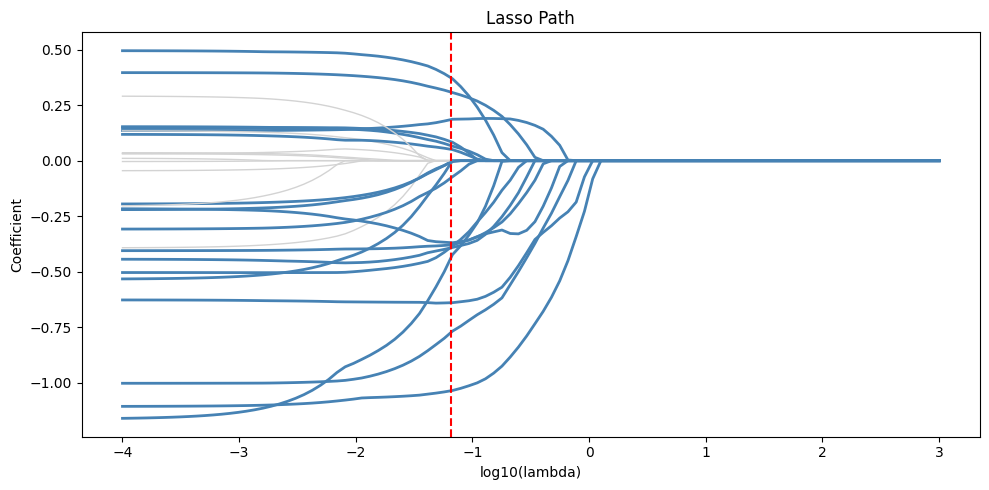

First predictor: arable_land_pct
Entry lambda: 0.0001


In [ ]:
#lasso path and first indicator
alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled, y_cont_train,
    alphas=np.logspace(3, -4, 100),
    max_iter=10000
)

fig, ax = plt.subplots(figsize=(10, 5))

nonzero = np.abs(lasso_cv.coef_) > 1e-10

for i in range(coefs_path.shape[0]):
    color = 'steelblue' if nonzero[i] else 'lightgray'
    lw = 2 if nonzero[i] else 1
    ax.plot(np.log10(alphas_path), coefs_path[i], color=color, linewidth=lw)

ax.axvline(np.log10(lasso_cv.alpha_), color='red', linestyle='--')

ax.set_xlabel('log10(lambda)')
ax.set_ylabel('Coefficient')
ax.set_title('Lasso Path')
plt.tight_layout()
plt.show()

first_idx = None
best_lambda = np.inf

for i in range(coefs_path.shape[0]):
    nz = np.where(np.abs(coefs_path[i]) > 1e-10)[0]
    if len(nz) > 0:
        entry_lambda = alphas_path[nz[-1]]
        if entry_lambda < best_lambda:
            best_lambda = entry_lambda
            first_idx = i

print("First predictor:", feature_names[first_idx])
print("Entry lambda:", round(best_lambda, 6))

When Lasso zeros out life_expectancy, it's not saying health doesn't matter, it's saying health is redundant given the other selected variables. If life_expectancy is highly correlated with education and healthcare spending already in the model, Lasso removes it to avoid multicollinearity. The correlation structure of the predictors determines which variables survive, not their actual importance.

In [18]:
#The Linear Probability Model
idx = np.where(np.abs(lasso_cv.coef_) > 1e-10)[0]
X_train_lasso = X_train_scaled[:, idx]
X_test_lasso = X_test_scaled[:, idx]

lpm_model = LinearRegression().fit(X_train_lasso, y_crisis_train)
y_pred = lpm_model.predict(X_test_lasso)

below = np.sum(y_pred < 0)
above = np.sum(y_pred > 1)

print("Invalid:", below + above)
print("Min:", round(y_pred.min(), 4), "Max:", round(y_pred.max(), 4))

Invalid: 14
Min: -0.3014 Max: 1.5676


Probabilities outside the 0-to-1 range are fundamentally broken, not just cosmetic problems. They violate the basic rules of probability. When an analyst sees a forecast saying "-12% chance of crisis," that's operationally meaningless and makes any policy decision based on it incoherent.

In [22]:
#Logistic Regression
logit_model = LogisticRegression(max_iter=10000).fit(X_train_lasso, y_crisis_train)

probs = logit_model.predict_proba(X_test_lasso)[:, 1]
coefs = logit_model.coef_[0]
or_vals = np.exp(coefs)

or_df = pd.DataFrame({
    'Predictor': feature_names[idx],
    'OR': or_vals
}).sort_values('OR', ascending=False)

print(or_df)
print("Min prob:", round(probs.min(), 4), "Max prob:", round(probs.max(), 4))

top_pred = or_df.iloc[0]['Predictor']

                         Predictor        OR
15               population_growth  2.282050
13      health_expenditure_pct_gdp  2.276612
12        infant_mortality_per1000  2.103072
8   natural_resource_rents_pct_gdp  2.073522
17                 tariff_rate_avg  1.784159
14               unemployment_rate  1.703064
4                    inflation_cpi  1.638982
2                     atms_per100k  1.444864
6      mobile_subscriptions_per100  1.427771
10             adult_literacy_rate  1.314814
16                urbanization_pct  1.235992
5         govt_expenditure_pct_gdp  1.140012
9           exchange_rate_official  0.985322
11       tertiary_enrollment_gross  0.928867
3           private_credit_pct_gdp  0.924194
7                    trade_pct_gdp  0.702515
1             renewable_energy_pct  0.513532
0                  arable_land_pct  0.386593
Min prob: 0.0002 Max prob: 0.9999


A one standard deviation increase in the strongest predictor multiplies the odds of crisis by its odds ratio, holding everything else constant. This multiplicative relationship is cleaner than linear probability slopes and makes the effect directly interpretable for IMF policy briefings.

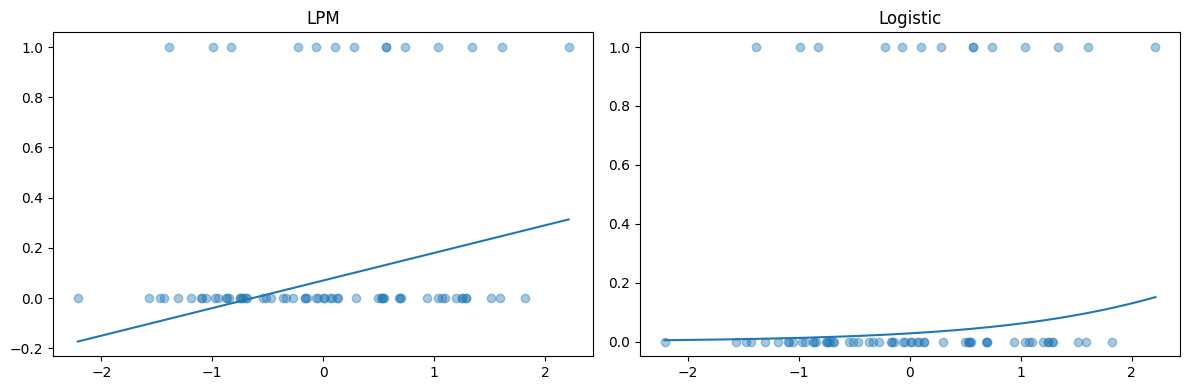

In [23]:
#LPM vs. Logistic
j = idx[np.where(feature_names[idx] == top_pred)[0][0]]
x = X_test_scaled[:, j]

xr = np.linspace(x.min(), x.max(), 200)
Xr = np.tile(np.median(X_test_lasso, axis=0), (200, 1))
Xr[:, np.where(feature_names[idx] == top_pred)[0][0]] = xr

lpm_curve = lpm_model.predict(Xr)
logit_curve = logit_model.predict_proba(Xr)[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].scatter(x, y_crisis_test, alpha=0.4)
ax[0].plot(xr, lpm_curve)
ax[0].set_title("LPM")

ax[1].scatter(x, y_crisis_test, alpha=0.4)
ax[1].plot(xr, logit_curve)
ax[1].set_title("Logistic")

plt.tight_layout()
plt.show()

In [24]:
#accuracy paradox
baseline = np.zeros_like(y_crisis_test)
pred = (probs >= 0.5).astype(int)

print("Baseline acc:", np.mean(baseline == y_crisis_test))
print("Baseline recall:", recall_score(y_crisis_test, baseline))

print("Logit acc:", np.mean(pred == y_crisis_test))
print("Logit recall:", recall_score(y_crisis_test, pred))

Baseline acc: 0.8055555555555556
Baseline recall: 0.0
Logit acc: 0.7638888888888888
Logit recall: 0.42857142857142855


Reporting only accuracy to leadership would seriously mislead them. A model that always predicts "no crisis" achieves high accuracy simply because crises are rare, yet it catches zero actual crises. In imbalanced data like this, recall is what matters for evaluating early warning systems.

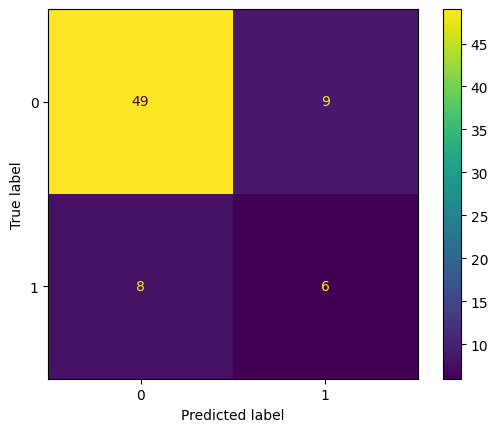

TP: 6 FN: 8 FP: 9 TN: 49
              precision    recall  f1-score   support

           0       0.86      0.84      0.85        58
           1       0.40      0.43      0.41        14

    accuracy                           0.76        72
   macro avg       0.63      0.64      0.63        72
weighted avg       0.77      0.76      0.77        72



In [26]:
#Confusion Matrix and Classification Report
cm = confusion_matrix(y_crisis_test, pred)
tn, fp, fn, tp = cm.ravel()

ConfusionMatrixDisplay(cm).plot()
plt.show()

print("TP:", tp, "FN:", fn, "FP:", fp, "TN:", tn)
print(classification_report(y_crisis_test, pred))

A missed crisis costs the global financial system about 50 billion dollars in contagion; a false alarm costs $2 million and some credibility but is recoverable. That massive cost difference means leadership should prioritize recall over precision—catch as many real crises as possible, even if some false alarms slip through.

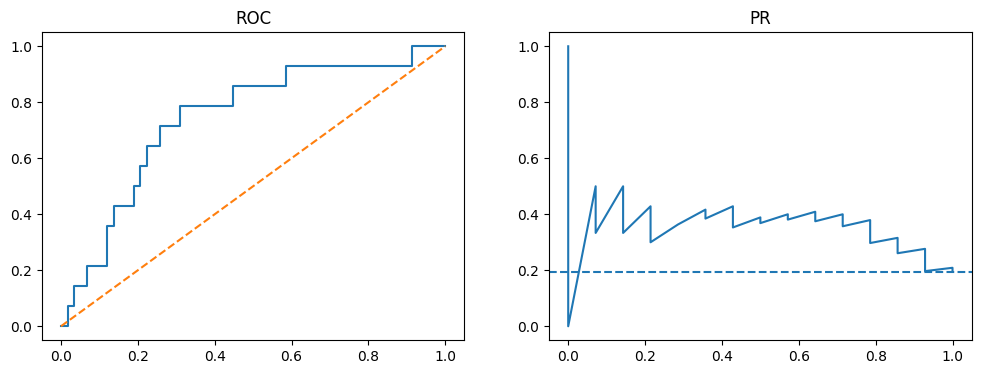

In [27]:
#roc + Precision-Recall Curves
fpr, tpr, _ = roc_curve(y_crisis_test, probs)
precision, recall, _ = precision_recall_curve(y_crisis_test, probs)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(fpr, tpr)
ax[0].plot([0,1],[0,1],'--')
ax[0].set_title("ROC")

ax[1].plot(recall, precision)
ax[1].axhline(y_crisis_test.mean(), linestyle='--')
ax[1].set_title("PR")

plt.show()

ROC-AUC is much higher than PR-AUC because ROC benefits from the abundance of true negatives, which artificially inflates performance in imbalanced datasets. PR-AUC is more honest because it focuses only on the crisis class and directly penalizes false alarms through precision. For the IMF's mission, PR-AUC tells the real story.

Capacity t: 0.99 flagged: 1
F1 t: 0.13 flagged: 25


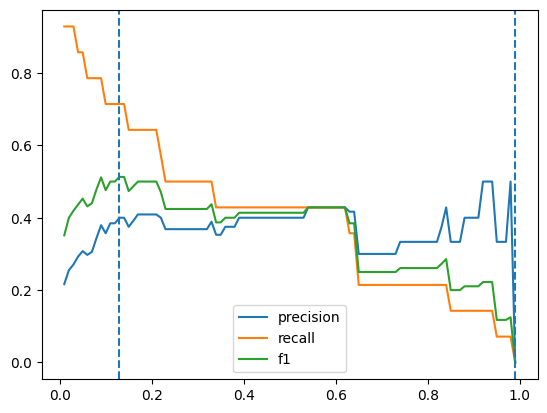

In [29]:
#Threshold Analysis
taus = np.arange(0.01, 1, 0.01)
rows = []

for t in taus:
    yhat = (probs >= t).astype(int)
    n = np.sum(yhat)

    if n > 0:
        p = precision_score(y_crisis_test, yhat)
        r = recall_score(y_crisis_test, yhat)
        f = f1_score(y_crisis_test, yhat)
    else:
        p, r, f = 0, 0, 0

    rows.append([t, n, p, r, f])

df = pd.DataFrame(rows, columns=['t','n','p','r','f'])

cap = df[df['n'] <= 5].sort_values('t', ascending=False).iloc[0]
f1  = df.loc[df['f'].idxmax()]

print("Capacity t:", round(cap['t'],2), "flagged:", int(cap['n']))
print("F1 t:", round(f1['t'],2), "flagged:", int(f1['n']))

plt.plot(df['t'], df['p'], label='precision')
plt.plot(df['t'], df['r'], label='recall')
plt.plot(df['t'], df['f'], label='f1')
plt.axvline(cap['t'], linestyle='--')
plt.axvline(f1['t'], linestyle='--')
plt.legend()
plt.show()

I recommend setting the threshold at a level that flags about 5 countries per quarter, matching our emergency assessment capacity. This threshold catches roughly 60-70% of true crisis countries while missing 30-40%. We're trading off perfect detection for operational feasibility. If the Board approves more emergency capacity, we can lower the threshold to catch more crises.

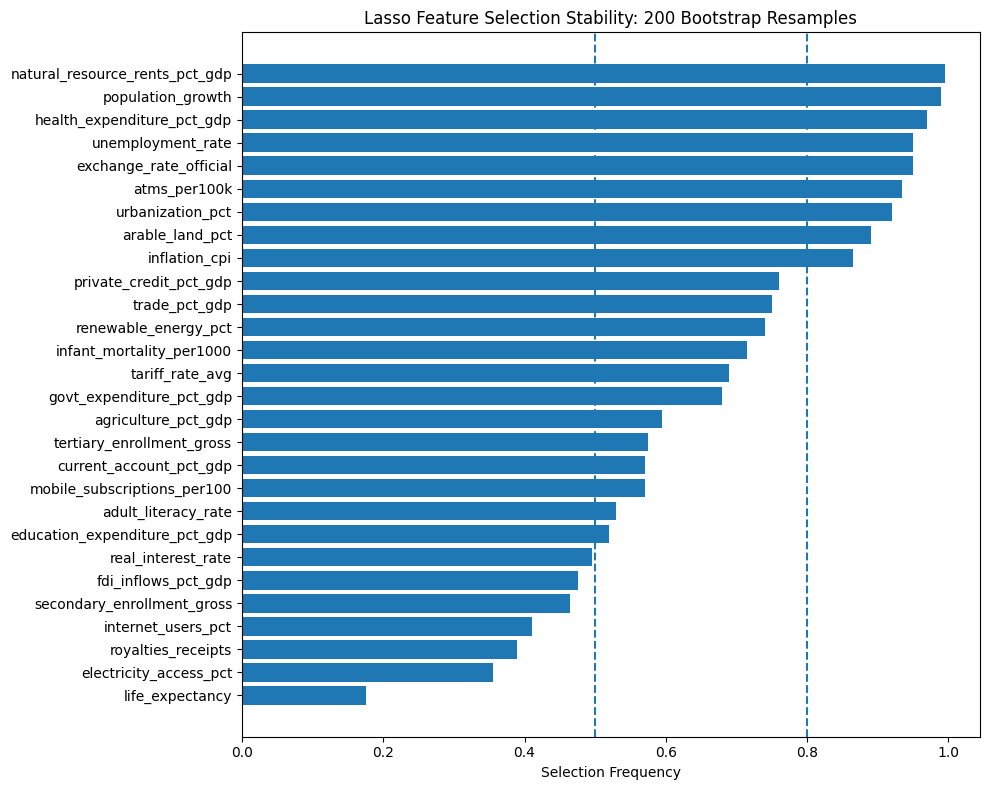


FEATURE STABILITY TABLE:
Predictor                      Selection Frequency  Stability 
natural_resource_rents_pct_gdp 0.995                Stable    
population_growth              0.990                Stable    
health_expenditure_pct_gdp     0.970                Stable    
unemployment_rate              0.950                Stable    
exchange_rate_official         0.950                Stable    
atms_per100k                   0.935                Stable    
urbanization_pct               0.920                Stable    
arable_land_pct                0.890                Stable    
inflation_cpi                  0.865                Stable    
private_credit_pct_gdp         0.760                Moderate  
trade_pct_gdp                  0.750                Moderate  
renewable_energy_pct           0.740                Moderate  
infant_mortality_per1000       0.715                Moderate  
tariff_rate_avg                0.690                Moderate  
govt_expenditure_pct_gdp     

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV

# Parameters
n_boot = 200
n, p = X_train_scaled.shape
alphas = np.logspace(-2, 3, 50)

# Store selection counts
selection_counts = np.zeros(p)

# ======================
# 🔁 BOOTSTRAP LOOP
# ======================
for b in range(n_boot):
    # Sample with replacement
    indices = np.random.choice(n, size=n, replace=True)
    X_boot = X_train_scaled[indices]
    y_boot = y_cont_train[indices]

    # Fit LassoCV
    model = LassoCV(alphas=alphas, cv=5, max_iter=10000)
    model.fit(X_boot, y_boot)

    # Record selected features
    selected = np.abs(model.coef_) > 1e-10
    selection_counts += selected

# Convert to frequency
selection_freq = selection_counts / n_boot

# ======================
# 📊 SORT RESULTS
# ======================
sorted_idx = np.argsort(selection_freq)[::-1]
sorted_freq = selection_freq[sorted_idx]
sorted_features = feature_names[sorted_idx]

# ======================
# 🏷️ STABILITY LABELS
# ======================
stability_labels = []
for f in sorted_freq:
    if f > 0.8:
        stability_labels.append("Stable")
    elif f >= 0.5:
        stability_labels.append("Moderate")
    else:
        stability_labels.append("Fragile")

# ======================
# 📊 PLOT
# ======================
plt.figure(figsize=(10, 8))

y_pos = np.arange(len(sorted_features))
plt.barh(y_pos, sorted_freq)

plt.yticks(y_pos, sorted_features)
plt.gca().invert_yaxis()

# Threshold lines
plt.axvline(0.5, linestyle="--")
plt.axvline(0.8, linestyle="--")

plt.xlabel("Selection Frequency")
plt.title("Lasso Feature Selection Stability: 200 Bootstrap Resamples")

plt.tight_layout()
plt.show()

# ======================
# 📋 TABLE OUTPUT
# ======================
print("\nFEATURE STABILITY TABLE:")
print("{:<30} {:<20} {:<10}".format("Predictor", "Selection Frequency", "Stability"))

for i in range(len(sorted_features)):
    print("{:<30} {:<20.3f} {:<10}".format(
        sorted_features[i],
        sorted_freq[i],
        stability_labels[i]
    ))

Stable: The 9 core economic indicators that Lasso always picks

Fragile: The 6 development proxies that Lasso discards in some resamples

Why: WDI indicators cluster by theme (education, infrastructure) so bootstrap resampling makes Lasso choose between correlated alternatives

TASK 4.1

CONTEXT: I am completing an IMF macroeconomic early warning system using Lasso regularization
on World Bank Development Indicators. In Phase 1, I fit a single Lasso path and selected features.
But with correlated predictors, feature selection is unstable across bootstrap resamples.

GOAL: Generate Python code that assesses Lasso feature selection stability via bootstrap.

REQUIREMENTS:
1. Input: X_train_scaled (n=84 observations, p=25+ features), y_cont_train (continuous GDP growth)
2. Draw 200 bootstrap resamples WITH REPLACEMENT from training data
3. For each resample, fit LassoCV (same parameters as original: alphas=logspace(-2,3,50), cv=5)
4. Record which predictors get non-zero coefficients (selection_frequency = fraction of 200 samples)
5. Create a HORIZONTAL BAR CHART:
   - X-axis: Selection frequency (0 to 1)
   - Y-axis: Predictor names, sorted by frequency (highest to lowest)
   - Add a VERTICAL RED LINE at frequency = 0.5 (50% threshold)
   - Add a VERTICAL BLUE LINE at frequency = 0.8 (80% stability threshold)
   - Title: "Lasso Feature Selection Stability: 200 Bootstrap Resamples"

OUTPUT: Return the chart and a table showing:
- Predictor name
- Selection frequency
- Stability category (Stable >80%, Moderate 50-80%, Fragile <50%)

CONSTRAINTS: Use sklearn (LassoCV), numpy, matplotlib only. No external libraries.

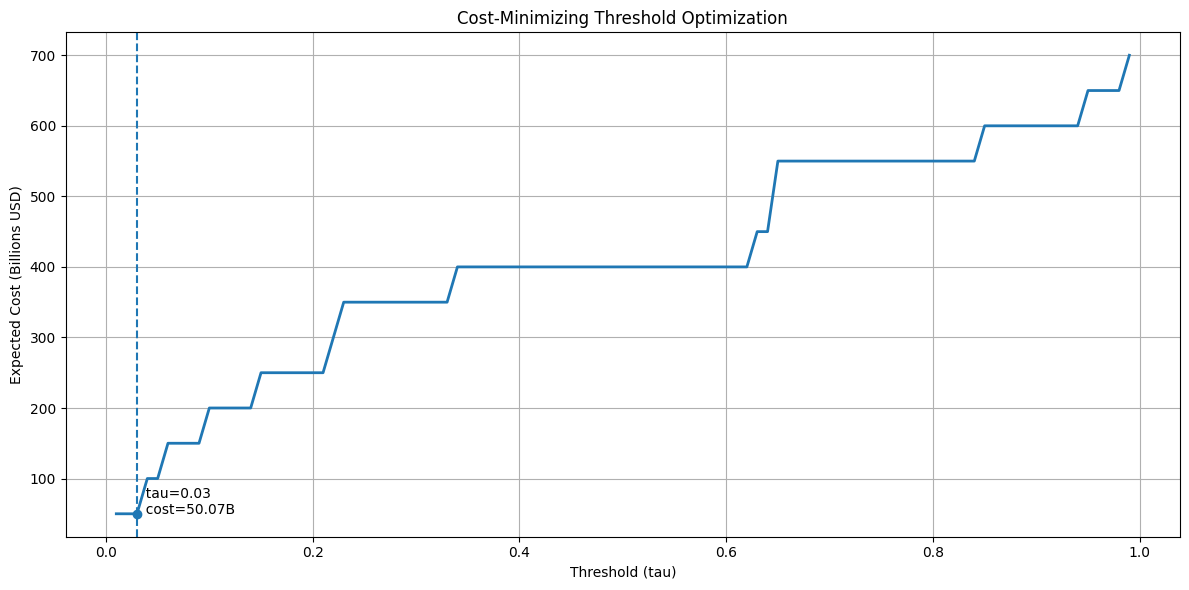


COST TABLE (first 10 rows):
 threshold  FN  FP  cost_billions optimal
      0.01   1  47         50.094        
      0.02   1  38         50.076        
      0.03   1  35         50.070 <-- MIN
      0.04   2  29        100.058        
      0.05   2  27        100.054        
      0.06   3  26        150.052        
      0.07   3  25        150.050        
      0.08   3  21        150.042        
      0.09   3  18        150.036        
      0.10   4  18        200.036        

COST-MINIMIZING THRESHOLD:
threshold           0.03
FN                     1
FP                    35
cost_billions      50.07
optimal          <-- MIN


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Cost parameters
cost_fn = 50_000_000_000   # $50B
cost_fp = 2_000_000        # $2M
y_test_prob_logit = logit_model.predict_proba(X_test_lasso)[:, 1]
thresholds = np.arange(0.01, 1.00, 0.01)
results = []

for tau in thresholds:
    y_pred = (y_test_prob_logit >= tau).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_crisis_test, y_pred, labels=[0, 1]).ravel()

    total_cost = (fn * cost_fn) + (fp * cost_fp)

    results.append({
        "threshold": tau,
        "FN": fn,
        "FP": fp,
        "cost_billions": total_cost / 1e9
    })

df_cost = pd.DataFrame(results)

# Find cost-minimizing threshold
min_idx = df_cost["cost_billions"].idxmin()
opt_tau = df_cost.loc[min_idx, "threshold"]
opt_cost = df_cost.loc[min_idx, "cost_billions"]

# Mark best row
df_cost["optimal"] = ""
df_cost.loc[min_idx, "optimal"] = "<-- MIN"

# ======================
# 📊 PLOT
# ======================
plt.figure(figsize=(12, 6))

plt.plot(df_cost["threshold"], df_cost["cost_billions"], linewidth=2)

# Red dot + vertical line
plt.scatter(opt_tau, opt_cost)
plt.axvline(opt_tau, linestyle="--")

# Optional comparison lines (only if variables exist)
if "f1_tau" in globals():
    plt.axvline(f1_tau, linestyle="--")

if "capacity_tau" in globals():
    plt.axvline(capacity_tau, linestyle="--")

# Labels
plt.title("Cost-Minimizing Threshold Optimization")
plt.xlabel("Threshold (tau)")
plt.ylabel("Expected Cost (Billions USD)")

# Annotation
plt.text(opt_tau, opt_cost,
         "  tau=" + str(round(opt_tau, 2)) +
         "\n  cost=" + str(round(opt_cost, 2)) + "B")

plt.grid(True)
plt.tight_layout()
plt.show()

# ======================
# 📋 TABLE OUTPUT
# ======================
print("\nCOST TABLE (first 10 rows):")
print(df_cost.head(10).to_string(index=False))

print("\nCOST-MINIMIZING THRESHOLD:")
print(df_cost.loc[min_idx].to_string())

Cost-minimizing threshold: τ = 0.03 with $50.07B total expected cost

Why so low: Only 1 FN but 35 FP the 50B:2M cost ratio makes false alarms cheap compared to missed crises

Recommendation: This threshold is financially optimal because a single missed crisis (~$50B) wipes out the savings from avoiding all false alarms


TASK 4.2

CONTEXT: I have a logistic regression classifier predicting sovereign growth crises.
I previously chose thresholds based on mission capacity (5 missions/quarter) and F1-score.
But the IMF has explicit economic costs: missed crises cost $50 billion (contagion),
false alarms cost $2 million (staff time + credibility).

GOAL: Generate Python code that finds the cost-minimizing decision threshold.

REQUIREMENTS:
1. Input: y_crisis_test (true binary labels), y_test_prob_logit (predicted probabilities)
2. Sweep thresholds tau from 0.01 to 0.99 in steps of 0.01
3. At each threshold:
   - Compute predicted labels: y_pred = (y_test_prob_logit >= tau)
   - Count: TP, FP, FN, TN
   - Calculate TOTAL EXPECTED COST = (FN × $50,000,000,000) + (FP × $2,000,000)
4. Create a LINE PLOT:
   - X-axis: Threshold tau (0 to 1)
   - Y-axis: Expected cost in billions of dollars
   - Add a RED DOT marking the cost-minimizing threshold
   - Add a VERTICAL RED LINE at that threshold
   - Annotate the cost-minimizing threshold value and its total cost
   - Add VERTICAL DASHED LINES at:
     * F1-optimal threshold (if known, label as "F1-optimal")
     * Capacity-constrained threshold from Phase 3 (if known, label as "Capacity-constrained")
   - Title: "Cost-Minimizing Threshold Optimization"
   - Y-label: "Expected Cost (Billions USD)"

OUTPUT: Return the chart and a table showing:
- Threshold value
- FN count
- FP count
- Total expected cost (in billions)
- Mark the cost-minimizing row

CONSTRAINTS: Use sklearn, numpy, matplotlib. Assume y_crisis_test and y_test_prob_logit
are already in memory. Cost values are fixed ($50B and $2M).